# 07 — How complex were the formulae themselves?

Produces **Supplementary Figure 1**, "Metrics Comparison Across Models and
Complexities for Formulae generation".

The paper's central claim is about *compression*. A model that has understood a
sequence should be able to answer with something **shorter** than the sequence —
a rule, not a restatement. So the test is not only whether the answer is right,
but how complex the answer itself is.

Six panels, each a different complexity measure applied to the formulae the
models wrote, plotted against the complexity of the target sequence. If the
models were compressing, these lines would be flat or falling. They rise.

**No logic lives in this notebook.** Everything comes from
`superarc.compression_metrics`.

In [1]:
import pandas as pd
from IPython.display import Image

from superarc.compression_metrics import (
    DATASET,
    METRICS,
    PLACEHOLDER,
    PLACEHOLDER_EXPECTATION,
    compute,
    estimate_placeholder_expectation,
    per_string_measures,
    placeholder_census,
    plot,
)

pd.set_option("display.width", 140)
print(DATASET.name)

formulas_found_by_llm.csv


## The missing answers, and why they decide everything

A cell reading `***` means the model produced **no formula at all**. That is not
a gap in the data — it is a result, and it has to be scored.

Look at how much of the dataset this is.

In [2]:
census = placeholder_census()

print(f"total answers : {census['answers'].sum()}")
print(f"missing       : {census['missing'].sum()}  "
      f"({100 * census['missing'].sum() / census['answers'].sum():.1f}%)")

census.groupby("model")[["answers", "missing"]].sum().assign(
    **{"missing %": lambda d: (100 * d["missing"] / d["answers"]).round(1)}
).sort_values("missing %", ascending=False)

total answers : 1955
missing       : 550  (28.1%)


,answers,missing,missing %
model,,,
chatgpt_o1,85,46,54.1
mistral_large2405,85,44,51.8
chatgpt_4_5,85,41,48.2
claude_sonnet_4,85,37,43.5
grok_3,85,36,42.4
grok_4,85,34,40.0
gemini_thinking,85,33,38.8
gemini_2_5_pro,85,32,37.6
qwen3,85,32,37.6


### Scoring a missing answer

Here is the trap. If `***` is measured as written, it is three characters, and
three characters compress beautifully. A model that answered *nothing* would
score as having given the **best-compressing answer in the dataset** — the exact
opposite of what happened.

So the original replaced every `***` with a long, high-entropy string, making
"no answer" score as *incompressible*. That is the right call. Compare the two
treatments on a single answer:

In [3]:
pd.DataFrame({
    "'***' measured as written": per_string_measures(PLACEHOLDER),
    "a real formula, 'n**2'": per_string_measures("n**2"),
    "placeholder (expectation)": PLACEHOLDER_EXPECTATION,
}).round(2)

,'***' measured as written,"a real formula, 'n**2'",placeholder (expectation)
avg_bdm,62.72,63.03,958.55
avg_shannon,1.00,1.00,4.87
avg_lzw,80.00,80.00,140.00
avg_zip,16.00,16.00,71.99
avg_bdm_lzw,1510.30,1498.24,2556.53
avg_bdm_zip,293.50,331.90,1511.04


Read the first two columns together. On `avg_lzw` and `avg_zip` they are
**identical** (80.0 and 16.0), and on `avg_bdm_lzw` the empty answer scores
*higher* than the real one. A missing answer is simply indistinguishable from a
short, compact formula — which is precisely the failure. Both sit far below the
placeholder on all six measures.

So scoring `***` as written would credit a model that said nothing with having
given a short, elegant answer.

### Why there is no seed here

The original drew that string at random and never seeded it, so the exact
published image came from one arbitrary draw nobody recorded.

It does not need a seed. Each panel is a **mean** over answers, and the original
gave every missing cell the *same* string — so each panel is linear in one
quantity: the measure of a single 45-character string. Averaging the figure over
infinitely many draws is therefore exactly substituting that quantity's
**expectation**, which is what happens now.

The constants are not asserted. Re-estimate them here:

In [4]:
estimate_placeholder_expectation(draws=500, seed=11).round(4).assign(
    pinned=pd.Series(PLACEHOLDER_EXPECTATION)
)

,expectation,sd,standard error,pinned
avg_bdm,958.4846,25.2905,1.1310,958.5531
avg_shannon,4.8676,0.0504,0.0023,4.8681
avg_lzw,140.0000,0.0000,0.0000,140.0000
avg_zip,71.9920,0.1789,0.0080,71.9910
avg_bdm_lzw,2557.7500,59.0013,2.6386,2556.5311
avg_bdm_zip,1510.7064,41.6337,1.8619,1511.0446


`avg_lzw` has a standard deviation of exactly **zero**: LZMA of any 45-character
alphanumeric string base64-encodes to exactly 140 characters, every time. That
is why the Avg LZW panel never showed any sensitivity to the draw.

## The table behind the figure

In [5]:
table = compute()

table.pivot_table(index=["measure", "complexity"], columns="model", values="value").round(1)

model                   chatgpt_4_5  chatgpt_4o  chatgpt_5  chatgpt_o1  claude_3_5_sonnet  claude_3_7  claude_sonnet_4  cursor_small  \
measure     complexity                                                                                                                 
avg_bdm     1                  97.9        68.0       65.8        68.0               68.0        68.0            107.4          97.9   
            2                 576.6       311.5      420.9       635.6              316.2       292.8            516.6         206.4   
            3                 902.3       713.4      838.0       958.6              713.4       455.1            852.5         829.0   
avg_bdm_lzw 1                1536.8      1502.6     1499.2      1502.6             1502.6      1502.6           1549.0        1536.8   
            2                2117.6      1899.0     1948.9      2183.8             1903.7      1859.1           2044.8        1720.9   
            3                2493.2      2424.9     2428.4      2556.5             2424.9      2079.6           2432.2        2412.8   
avg_bdm_zip 1                 370.8       347.5      344.1       347.5              347.5       347.5            367.8         370.8   
            2                1009.9       714.8      796.9      1089.8              710.7       681.8            925.0         539.9   
            3                1438.0      1241.5     1356.2      1511.0             1241.5       916.2           1372.2        1343.8   
avg_lzw     1                  85.2        82.8       82.5        82.8               82.8        82.8             85.2          85.2   
            2                 115.1       104.2      105.4       119.4              104.0       101.8            111.7          92.3   
            3                 136.5       131.2      132.4       140.0              131.2       116.4            133.3         131.7   
avg_shannon 1                   1.3         0.9        0.9         0.9                0.9         0.9              1.7           1.3   
            2                   3.5         2.6        3.1         3.6                2.7         2.7              3.3           2.2   
            3                   4.7         4.3        4.5         4.9                4.3         3.2              4.5           4.4   
avg_zip     1                  18.6        17.4       17.2        17.4               17.4        17.4             18.6          18.6   
            2                  48.1        34.6       38.5        52.0               34.2        32.6             44.0          26.2   
            3                  68.5        59.6       64.8        72.0               59.6        44.1             65.3          64.1   

model                   deepseek  deepseek_r1_0525  ...  grok_3  grok_4  llama_4_scout    meta  mistral  mistral_large2405  o1_mini  \
measure     complexity                              ...                                                                               
avg_bdm     1              210.6             210.6  ...    65.8   106.9          107.4   299.2     76.5              104.6     68.0   
            2              430.2             430.2  ...   518.2   484.4          440.2   676.9     96.5              579.4    362.6   
            3              869.9             869.9  ...   857.4   850.1          608.7   957.1    843.6              958.6    713.4   
avg_bdm_lzw 1             1736.6            1736.6  ...  1499.2  1575.5         1549.0  1819.4   1514.1             1545.1   1502.6   
            2             1988.2            1988.2  ...  2061.1  2052.6         2101.5  2241.7   1564.1             2118.5   1964.4   
            3             2462.3            2462.3  ...  2439.8  2436.4         2379.9  2554.2   2429.7             2556.5   2424.9   
avg_bdm_zip 1              560.6             560.6  ...   344.1   374.1          367.8   664.5    342.9              379.4    347.5   
            2              822.6             822.6  ...   936.1 

In [6]:
# The claim the figure makes, in one line: does every measure rise with complexity?
means = table.groupby(["measure", "complexity"])["value"].mean().unstack().round(2)
means.assign(**{"rises?": means.apply(lambda r: r[1] < r[2] < r[3], axis=1)})

complexity,1,2,3,rises?
measure,,,,
avg_bdm,140.33,442.42,820.03,True
avg_bdm_lzw,1605.11,2004.31,2441.59,True
avg_bdm_zip,439.26,848.32,1346.98,True
avg_lzw,87.62,108.73,133.18,True
avg_shannon,1.67,3.14,4.46,True
avg_zip,21.66,40.79,64.36,True


Every measure rises. The answers get **more** complex as the target does — the
models are not compressing, they are elaborating.

## The figure

/Users/alberto/Documents/projects/medLLM/outputs/latest/figure10.pdf
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure10.svg
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure10.png


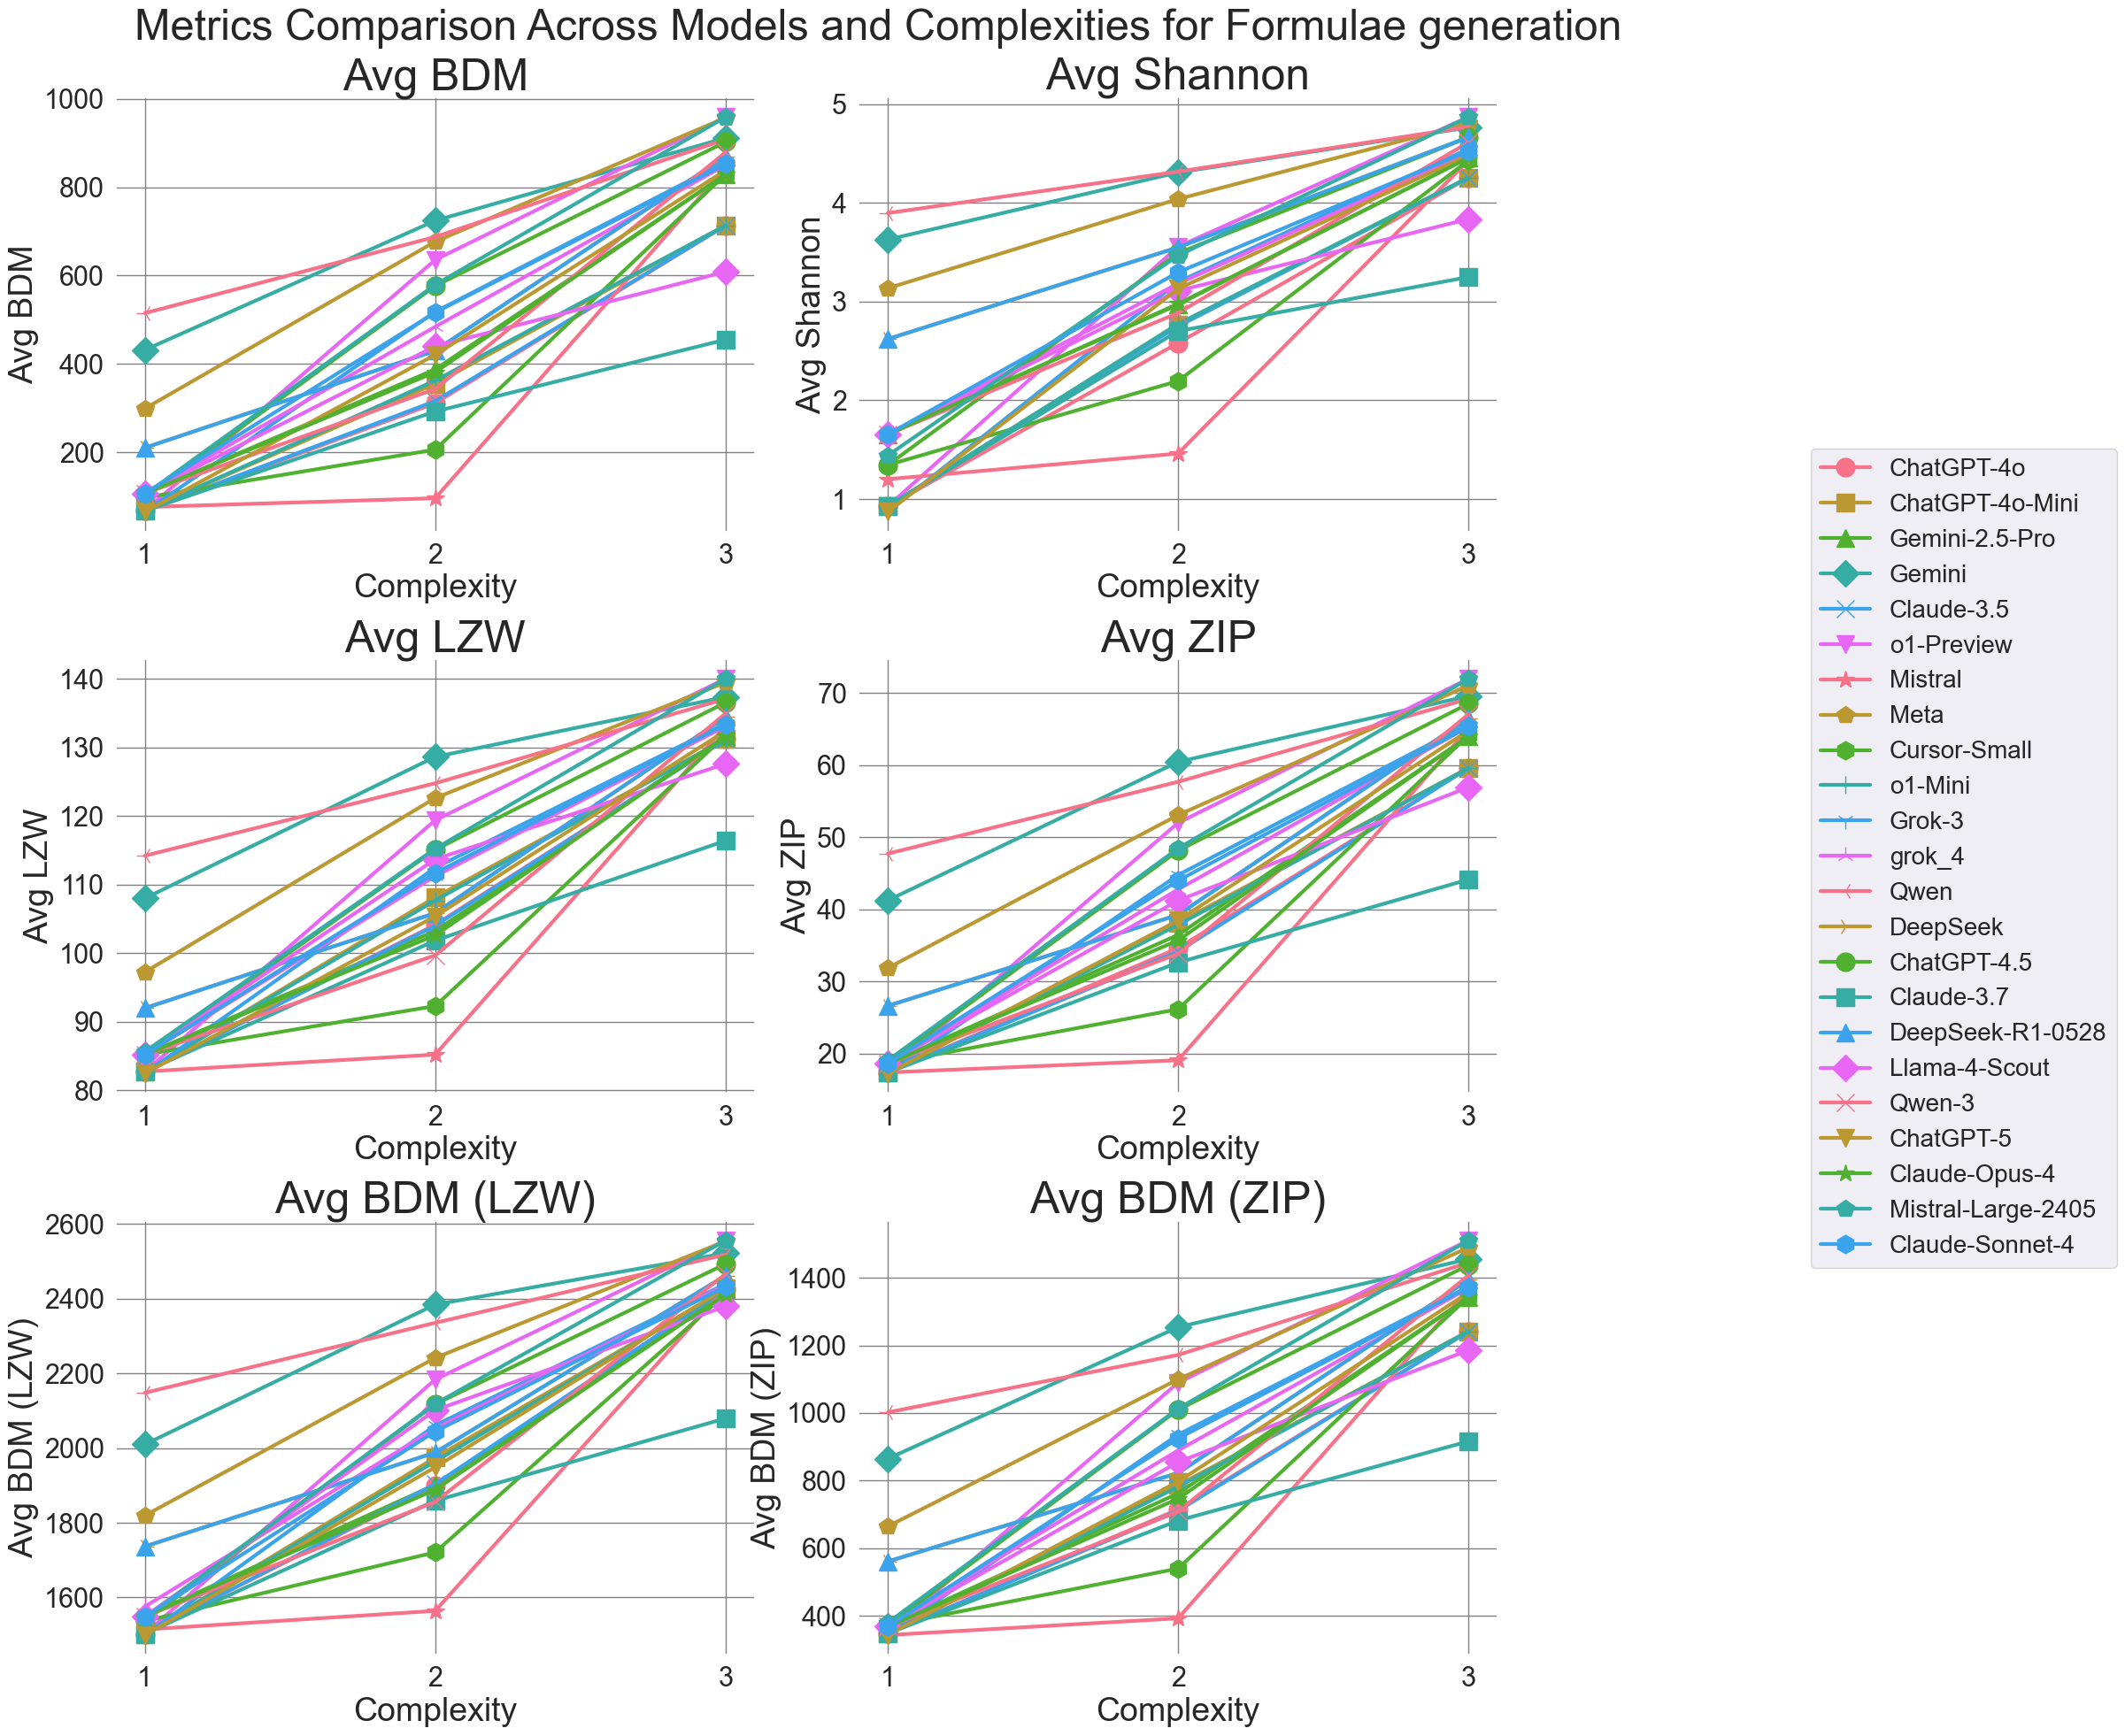

In [7]:
written = plot(table)
for path in written:
    print(path)

Image(filename=str(next(p for p in written if p.suffix == ".png")))

### Two things to notice in the legend

`grok_4` is printed in the raw column style while every other model is formatted
(`Grok-3`, `Qwen-3`, …). The display map's key is `grok4` where the model is
`grok_4`, so the lookup fell through to the default. It is printed that way in
the Supplementary Information, so it is reproduced that way here. Fixing it is
an author's call.

`DeepSeek-R1-0528` appears here, while the formulae figures print
`DeepSeek-R1-0525`. One model, two labels in the published paper.

## Verification

In [8]:
# Determinism: no seed appears in the result, so two runs must agree exactly.
again = compute()
merged = table.merge(again, on=["model", "complexity", "measure"], suffixes=("_a", "_b"))
print(f"{(merged.value_a == merged.value_b).sum()}/{len(merged)} values identical across two runs")

414/414 values identical across two runs


In [9]:
from superarc.parity import check_figures

check_figures(["figure10.png"])

,figure,status,detail
0,figure10.png,changed,SI Fig 1 formulae complexity -- AVERAGED OVER...


In [10]:
import subprocess

dirty = subprocess.run(
    ["git", "status", "--porcelain", "new_plots/", "plots/"],
    capture_output=True, text=True,
).stdout.strip()

print(dirty if dirty else "clean: no published figure was modified")

clean: no published figure was modified


The figure regenerates about **4.6%** of pixels away from the published image,
and that is the expected result rather than a defect. The published image is one
draw from a distribution; this is the distribution's centre. Two different seeds
land 3–6% from *each other*, so a single lucky seed being closer means nothing.

What the figure shows — every measure rising with complexity — is far larger
than that wobble and does not depend on it at all.